In [1]:
import pandas as pd
from pathlib import Path

In [2]:
LME = Path.cwd() / "data" / "lme_aluminium.csv"
MWP_M = Path.cwd() / "data" / "midwest_premium.csv"
US_IMPORTS = Path.cwd() / "data" / "us_imports_by_country.csv"
MWP_FUTURES= Path.cwd() / "data" / "midwest_premium_curve.csv"
DUP = Path.cwd() / "data" / "europe_duty_unpaid_premium.csv"
DP = Path.cwd() / "data" / "europe_duty_paid_premium.csv"
CANADA_EXPORTS = Path.cwd() / "data" / "canada_exports_by_country.csv"

In [3]:
lme = pd.read_csv(LME)
mwp_m = pd.read_csv(MWP_M)
mwp_futures = pd.read_csv(MWP_FUTURES)
dp = pd.read_csv(DP)

lme['date'] = pd.to_datetime(lme['date'])
mwp_m['date'] = pd.to_datetime(mwp_m['date'])
mwp_futures['date'] = pd.to_datetime(mwp_futures['date'])
dp['date'] = pd.to_datetime(dp['date'])

In [4]:
lme.columns

Index(['date', 'cash', 'three_month', 'stock'], dtype='object')

In [5]:
# Look at the landed cost (LME + DP + freight + tariff) vs. MW physical (LME + MWP)
# Before and after tariffs in june 4 2025

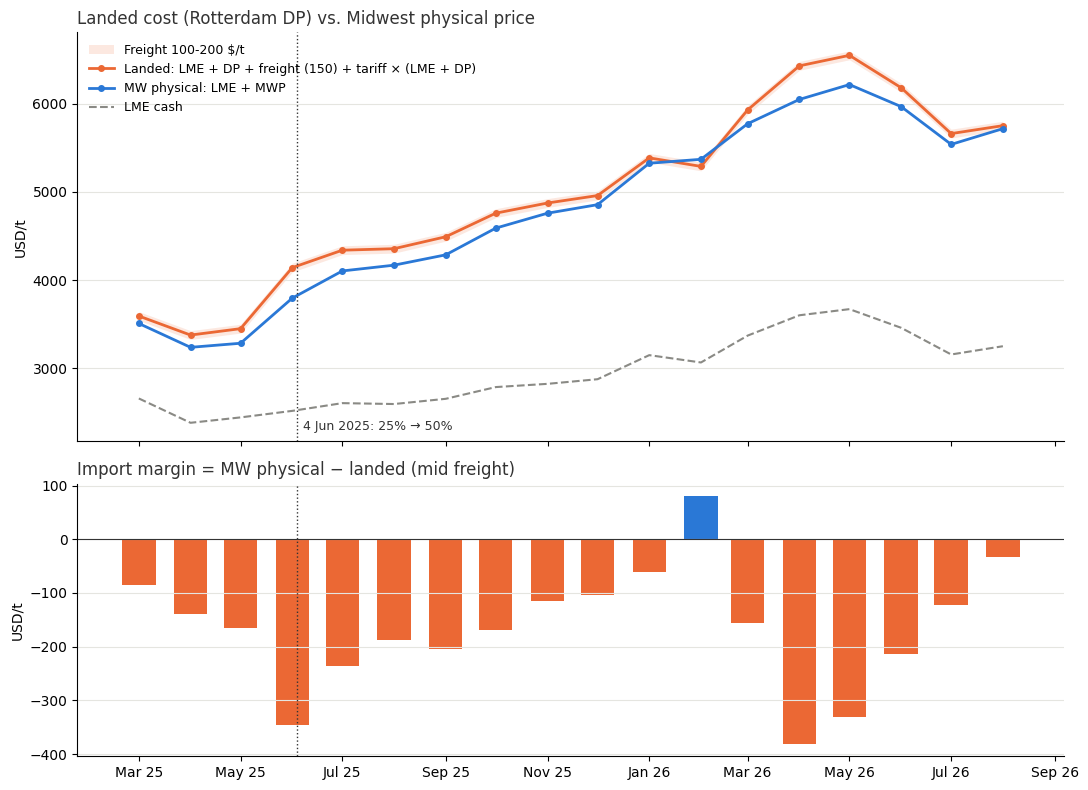

,before (Apr-May 25),after (Jul 25 on),change
mw_physical,3260.0,5194.0,1934.0
landed,3413.0,5354.0,1941.0
gap,-152.0,-160.0,-8.0
mwp,848.0,2119.0,1271.0
tariff,653.0,1735.0,1082.0


In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Freight Rotterdam -> Midwest (USD/t): assumption, no free series. Mid + low/high band.
FREIGHT_LOW, FREIGHT_MID, FREIGHT_HIGH = 100, 150, 200
TARIFF_DATE = pd.Timestamp("2025-06-04")

# Monthly averages (month start index)
lme_m = lme.set_index("date")["cash"].resample("MS").mean().rename("lme")
dp_m = dp.set_index("date")["premium_usd_t"].rename("dp")
mwp_hist = mwp_m.set_index("date")["premium_usd_t"]
# Extend MWP past USGS coverage with the M01 futures settle at month-end
m01 = (mwp_futures[mwp_futures["tenor"] == 1].set_index("date")["premium_usd_t"]
       .resample("MS").last())
mwp_all = mwp_hist.combine_first(m01).rename("mwp")

df = pd.concat([lme_m, dp_m, mwp_all], axis=1).dropna()

# Section 232 rate by origin: (effective date, rate). Canada was exempt from 20 May 2019 until exemptions ended
# on 12 Mar 2025; other origins paid 10% until then. The 16 Aug-15 Sep 2020 reimposition on Canada is left out
# (it hit only part of Canadian unwrought metal and predates the price data used here).
TARIFF_STEPS = {
    "Canada": [("2019-05-20", 0.00), ("2025-03-12", 0.25), ("2025-06-04", 0.50)],
    "Other":  [("2018-03-23", 0.10), ("2025-03-12", 0.25), ("2025-06-04", 0.50)],
}

def tariff_rate(month_start, origin="Other"):
    """Day-weighted average rate over the month, so Mar 2025 and Jun 2025 blend the two regimes."""
    days = pd.date_range(month_start, month_start + pd.offsets.MonthEnd(0), freq="D")
    steps = pd.Series({pd.Timestamp(d): r for d, r in TARIFF_STEPS[origin]})
    return steps.reindex(steps.index.union(days)).ffill().loc[days].mean()

df["tariff_rate"] = [tariff_rate(d) for d in df.index]
df["fob"] = df["lme"] + df["dp"]
df["tariff"] = df["tariff_rate"] * df["fob"]
df["landed"] = df["fob"] + FREIGHT_MID + df["tariff"]
df["landed_low"] = df["fob"] + FREIGHT_LOW + df["tariff"]
df["landed_high"] = df["fob"] + FREIGHT_HIGH + df["tariff"]
df["mw_physical"] = df["lme"] + df["mwp"]
df["gap"] = df["mw_physical"] - df["landed"]   # >0: importing pays; <0: tariff not fully passed through

# The 25% rate only applied to all origins from 12 Mar 2025, so start the window there
plot = df.loc["2025-03-01":]

BLUE, ORANGE, INK, MUTED = "#2a78d6", "#eb6834", "#333333", "#8a8a85"
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                               gridspec_kw={"height_ratios": [3, 2]})

ax1.fill_between(plot.index, plot["landed_low"], plot["landed_high"], color=ORANGE, alpha=0.15, lw=0,
                 label=f"Freight {FREIGHT_LOW}-{FREIGHT_HIGH} $/t")
ax1.plot(plot.index, plot["landed"], color=ORANGE, lw=2, marker="o", ms=4,
         label=f"Landed: LME + DP + freight ({FREIGHT_MID}) + tariff × (LME + DP)")
ax1.plot(plot.index, plot["mw_physical"], color=BLUE, lw=2, marker="o", ms=4,
         label="MW physical: LME + MWP")
ax1.plot(plot.index, plot["lme"], color=MUTED, lw=1.5, ls="--", label="LME cash")
ax1.set_ylabel("USD/t")
ax1.set_title("Landed cost (Rotterdam DP) vs. Midwest physical price", loc="left", color=INK)
ax1.legend(loc="upper left", frameon=False, fontsize=9)

gap_colors = [BLUE if g >= 0 else ORANGE for g in plot["gap"]]
ax2.bar(plot.index, plot["gap"], width=20, color=gap_colors)
ax2.axhline(0, color=INK, lw=0.8)
ax2.set_ylabel("USD/t")
ax2.set_title("Import margin = MW physical − landed (mid freight)", loc="left", color=INK)

for ax in (ax1, ax2):
    ax.axvline(TARIFF_DATE, color=INK, lw=1, ls=":")
    ax.grid(axis="y", color="#e5e5e0", lw=0.8)
    ax.spines[["top", "right"]].set_visible(False)
ax1.annotate("4 Jun 2025: 25% → 50%", xy=(TARIFF_DATE, ax1.get_ylim()[0]), xytext=(4, 8),
             textcoords="offset points", fontsize=9, color=INK)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
fig.tight_layout()
plt.show()

# Average levels before / after the 4 Jun step (full months only)
pre, post = df.loc["2025-04-01":"2025-05-01"], df.loc["2025-07-01":]
summary = pd.DataFrame({"before (Apr-May 25)": pre[["mw_physical", "landed", "gap", "mwp", "tariff"]].mean(),
                        "after (Jul 25 on)": post[["mw_physical", "landed", "gap", "mwp", "tariff"]].mean()}).round(0)
summary["change"] = summary.iloc[:, 1] - summary.iloc[:, 0]
summary

takeaway: physical and landed price rose together, respectively by 1934$ and 1941$, indicating full passthrough of tariff costs. However, the import margin is still negative. One thing to note is that the import margin has a magnitude of 100-200 for most months, which is the same magnitude as the freight cost assumption, so changes in the freight cost can significantly alter the margins.

note: MWP after june 2026 is the front-month futures settle at month-end (since USGS monthly series stops at june 2026)

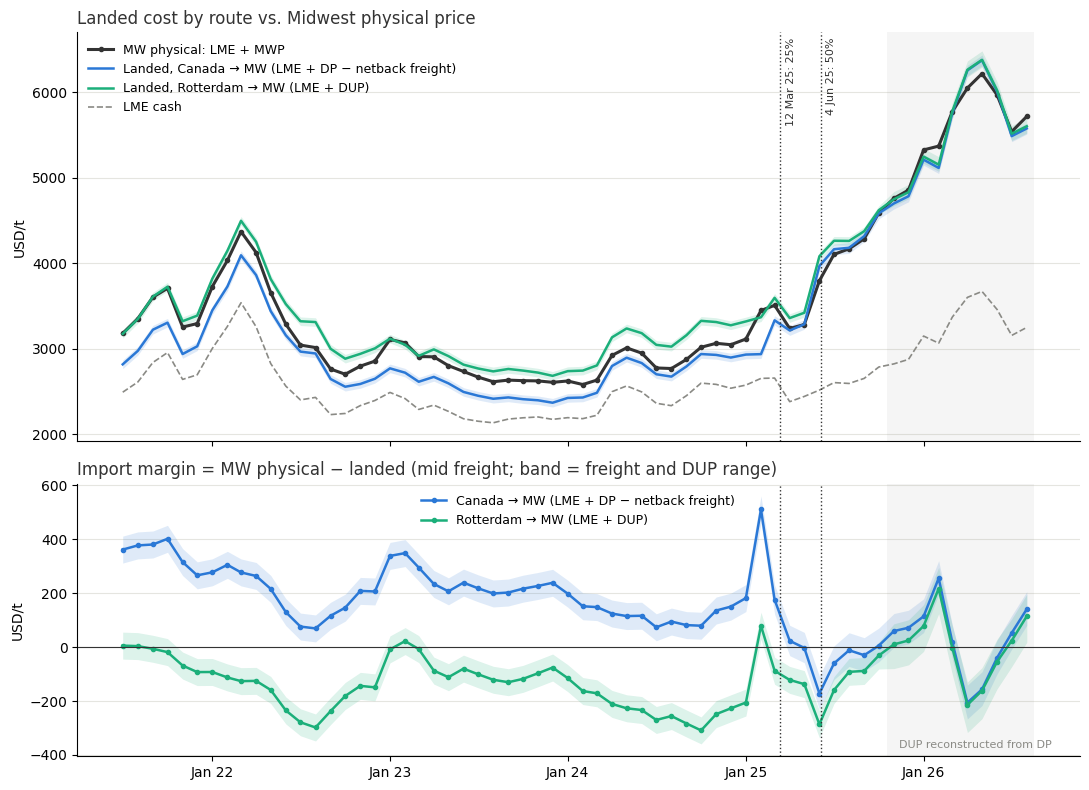

,Nov 24–Jan 25 (pre),Apr–May 25 (25%),Jul 25 on (50%)
mw_physical,3075.0,3260.0,5194.0
mwp,509.0,848.0,2119.0
landed_ca,2919.0,3250.0,5179.0
gap_ca,156.0,10.0,15.0
landed_rtm,3302.0,3390.0,5218.0
gap_rtm,-227.0,-130.0,-24.0


,step 1: 12 Mar 25 (25%),step 2: 4 Jun 25 (50%)
Canada,0.56,1.00
Rotterdam,2.10,1.06


In [7]:
# Landed cost by route, each with its own opportunity premium (see README, Method):
#   Rotterdam -> MW: FOB = LME + DUP. In-bond metal is re-exported uncleared, so the EU 3% duty is never paid.
#   Canada -> MW:    FOB = LME + DP - freight(Canada -> Rotterdam). Canadian metal enters the EU duty-free (CETA),
#                    so its alternative is the duty-paid price, netted back to Canada.
# Freight (USD/t) is an assumption, no free series: (low, mid, high)
FREIGHT = {
    "rtm_mw": (100, 150, 200),   # Rotterdam -> Midwest: transatlantic + inland
    "ca_rtm": (30, 50, 80),      # Canada -> Rotterdam: transatlantic, netback leg
    "ca_mw":  (30, 50, 80),      # Canada -> Midwest: rail / truck
}
dup_r = pd.read_csv(Path.cwd() / "data" / "europe_duty_unpaid_premium_reconstructed.csv", parse_dates=["date"]).set_index("date")

r = pd.concat([lme_m, dp_m, mwp_all,
               dup_r["premium_usd_t"].rename("dup"),
               dup_r[["dup_low", "dup_high"]].min(axis=1).rename("dup_lo"),
               dup_r[["dup_low", "dup_high"]].max(axis=1).rename("dup_hi"),
               dup_r["source"]], axis=1).dropna(subset=["lme", "dp", "mwp", "dup"])
r.loc[r["source"] == "observed", ["dup_lo", "dup_hi"]] = r["dup"]   # band only where DUP is reconstructed
r["mw_physical"] = r["lme"] + r["mwp"]
r["t_ca"] = [tariff_rate(d, "Canada") for d in r.index]
r["t_ot"] = [tariff_rate(d, "Other") for d in r.index]

def landed_rtm(dup, f):
    fob = r["lme"] + dup
    return fob + f + r["t_ot"] * fob

def landed_ca(f_netback, f_mw):
    fob = r["lme"] + r["dp"] - f_netback
    return fob + f_mw + r["t_ca"] * fob

lo, mid, hi = 0, 1, 2
r["landed_rtm"] = landed_rtm(r["dup"], FREIGHT["rtm_mw"][mid])
r["landed_ca"] = landed_ca(FREIGHT["ca_rtm"][mid], FREIGHT["ca_mw"][mid])
# Cheapest / dearest combinations of freight (and DUP band) for the shaded ranges
r["landed_rtm_lo"] = landed_rtm(r["dup_lo"], FREIGHT["rtm_mw"][lo])
r["landed_rtm_hi"] = landed_rtm(r["dup_hi"], FREIGHT["rtm_mw"][hi])
r["landed_ca_lo"] = landed_ca(FREIGHT["ca_rtm"][hi], FREIGHT["ca_mw"][lo])   # larger netback freight = cheaper FOB
r["landed_ca_hi"] = landed_ca(FREIGHT["ca_rtm"][lo], FREIGHT["ca_mw"][hi])
for route in ["rtm", "ca"]:
    r[f"gap_{route}"] = r["mw_physical"] - r[f"landed_{route}"]
    r[f"gap_{route}_lo"] = r["mw_physical"] - r[f"landed_{route}_hi"]
    r[f"gap_{route}_hi"] = r["mw_physical"] - r[f"landed_{route}_lo"]

STEP1 = pd.Timestamp("2025-03-12")
GREEN = "#1baf7a"
ROUTES = {"ca": ("Canada → MW (LME + DP − netback freight)", BLUE),
          "rtm": ("Rotterdam → MW (LME + DUP)", GREEN)}
recon = r.index[r["source"] == "reconstructed"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                               gridspec_kw={"height_ratios": [3, 2]})
ax1.plot(r.index, r["mw_physical"], color=INK, lw=2.2, marker="o", ms=3, label="MW physical: LME + MWP")
for route, (label, color) in ROUTES.items():
    ax1.fill_between(r.index, r[f"landed_{route}_lo"], r[f"landed_{route}_hi"], color=color, alpha=0.15, lw=0)
    ax1.plot(r.index, r[f"landed_{route}"], color=color, lw=1.8, label=f"Landed, {label}")
    ax2.fill_between(r.index, r[f"gap_{route}_lo"], r[f"gap_{route}_hi"], color=color, alpha=0.15, lw=0)
    ax2.plot(r.index, r[f"gap_{route}"], color=color, lw=1.8, marker="o", ms=3, label=label)
if len(recon):
    for ax in (ax1, ax2):
        ax.axvspan(recon[0] - pd.Timedelta(days=15), recon[-1] + pd.Timedelta(days=15),
                   color=MUTED, alpha=0.08, lw=0)
    ax2.annotate("DUP reconstructed from DP", xy=(recon[0], ax2.get_ylim()[0]), xytext=(4, 6),
                 textcoords="offset points", fontsize=8, color=MUTED)
ax1.plot(r.index, r["lme"], color=MUTED, lw=1.2, ls="--", label="LME cash")
ax1.set_ylabel("USD/t")
ax1.set_title("Landed cost by route vs. Midwest physical price", loc="left", color=INK)
ax1.legend(loc="upper left", frameon=False, fontsize=9)
ax2.axhline(0, color=INK, lw=0.8)
ax2.set_ylabel("USD/t")
ax2.set_title("Import margin = MW physical − landed (mid freight; band = freight and DUP range)", loc="left", color=INK)
ax2.legend(loc="upper center", frameon=False, fontsize=9)
for ax in (ax1, ax2):
    for d in (STEP1, TARIFF_DATE):
        ax.axvline(d, color=INK, lw=1, ls=":")
    ax.grid(axis="y", color="#e5e5e0", lw=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
for d, txt in [(STEP1, "12 Mar 25: 25%"), (TARIFF_DATE, "4 Jun 25: 50%")]:
    ax1.annotate(txt, xy=(d, ax1.get_ylim()[1]), xytext=(4, -4), textcoords="offset points",
                 fontsize=8, color=INK, rotation=90, va="top")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
fig.tight_layout()
plt.show()

# Averages by regime (full months only) and pass-through beta = ΔMW physical / Δlanded per route and step
REGIMES = {
    "Nov 24–Jan 25 (pre)": ("2024-11-01", "2025-01-01"),
    "Apr–May 25 (25%)":    ("2025-04-01", "2025-05-01"),
    "Jul 25 on (50%)":     ("2025-07-01", None),
}
cols = ["mw_physical", "mwp", "landed_ca", "gap_ca", "landed_rtm", "gap_rtm"]
by_regime = pd.DataFrame({k: r.loc[a:b, cols].mean() for k, (a, b) in REGIMES.items()}).round(0)
keys = list(REGIMES)
# Rotterdam already paid 10% before step 1, so its Δlanded at step 1 is small and its β is noisy
beta = pd.DataFrame({
    name: {"Canada": d["mw_physical"] / d["landed_ca"], "Rotterdam": d["mw_physical"] / d["landed_rtm"]}
    for name, d in [("step 1: 12 Mar 25 (25%)", by_regime[keys[1]] - by_regime[keys[0]]),
                    ("step 2: 4 Jun 25 (50%)", by_regime[keys[2]] - by_regime[keys[1]])]
}).round(2)
display(by_regime)
beta


The graph above is the first version. It prices the landed cost off LME + DP for a single Rotterdam-style route. The graph below splits the two routes and uses each one's actual opportunity premium (README, Method). The Rotterdam route uses DUP, because in-bond metal never pays the EU duty. That lowers its landed cost by about (DP − DUP) × (1 + t), ≈ 140 $/t at 50%. The Canada route uses DP netted back by Canada → Rotterdam freight. Shaded months use DUP reconstructed from DP, and the band includes that reconstruction range.

Takeaway: _to fill in after reviewing the chart._


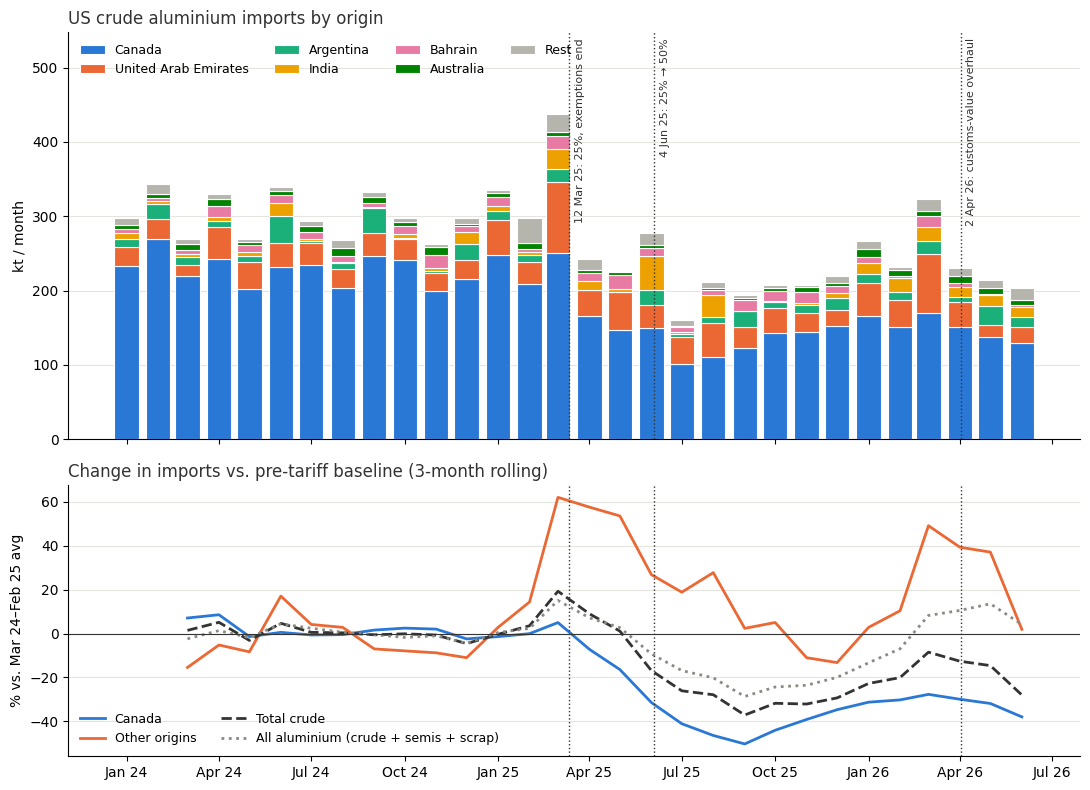

,Mar 24–Feb 25 (Canada 0%),Mar 25 (front-running),Apr–May 25 (25%),Jul 25–Mar 26 (50%),"Apr–Jun 26 (50%, new valuation)",50% vs. baseline (%)
country,,,,,,
Canada,224.5,250.0,156.5,140.2,139.3,-38.0
United Arab Emirates,30.5,95.6,43.0,38.8,23.9,27.0
Argentina,12.9,18.0,0.2,12.1,15.2,-6.0
India,6.1,27.4,8.1,10.8,13.9,77.0
Bahrain,9.8,17.5,14.7,9.8,3.1,0.0
Australia,7.0,5.4,3.9,5.6,7.9,-20.0
Rest,8.6,24.1,8.6,7.4,12.4,-14.0
Total crude,299.4,438.0,235.0,224.7,215.7,-25.0
All aluminium,463.9,619.0,405.0,401.4,483.0,-13.0


In [8]:
# US primary (crude, HTS 7601) imports by origin around the tariff steps
imports = pd.read_csv(US_IMPORTS, parse_dates=["date"])

EVENTS = {
    pd.Timestamp("2025-03-12"): "12 Mar 25: 25%, exemptions end",
    TARIFF_DATE:                "4 Jun 25: 25% → 50%",
    pd.Timestamp("2026-04-02"): "2 Apr 26: customs-value overhaul",
}

crude = (imports[imports["country"] != "Total"]
         .pivot_table(index="date", columns="country", values="crude_t", aggfunc="sum")
         .fillna(0))
total_crude = imports[imports["country"] == "Total"].set_index("date")["crude_t"]
total_all = imports[imports["country"] == "Total"].set_index("date")["total_t"]   # crude + semis + scrap

# Main origins: the largest crude suppliers since 2024; everything else folds into "Rest"
TOP_N = 5
top = (crude.loc["2024-01-01":].drop(columns="Other").sum()
       .sort_values(ascending=False).index[:TOP_N + 1].tolist())   # Canada + next 5
flows = crude[top].copy()
flows["Rest"] = total_crude - flows.sum(axis=1)   # residual so the stack equals the reported total
flows = flows.loc["2024-01-01":] / 1e3            # kt

SERIES_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#b5b4ad"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                               gridspec_kw={"height_ratios": [3, 2]})

bottom = pd.Series(0.0, index=flows.index)
for col, color in zip(flows.columns, SERIES_COLORS):
    ax1.bar(flows.index, flows[col], bottom=bottom, width=24, color=color,
            edgecolor="white", linewidth=0.8, label=col)
    bottom += flows[col]
ax1.set_ylabel("kt / month")
ax1.set_title("US crude aluminium imports by origin", loc="left", color=INK)
ax1.set_ylim(0, flows.sum(axis=1).max() * 1.25)
ax1.legend(loc="upper left", frameon=False, fontsize=9, ncol=4)

# Change vs. pre-tariff baseline (12 months to Feb 2025), 3-month rolling, by group
groups = pd.DataFrame({"Canada": flows["Canada"],
                       "Other origins": flows.drop(columns="Canada").sum(axis=1)})
groups["Total crude"] = groups.sum(axis=1)
groups["All aluminium (crude + semis + scrap)"] = total_all.loc["2024-01-01":] / 1e3
base_g = groups.loc["2024-03-01":"2025-02-01"].mean()
pct = (groups.rolling(3).mean() / base_g - 1) * 100
for col, color, ls in zip(pct.columns, [BLUE, ORANGE, INK, MUTED], ["-", "-", "--", ":"]):
    ax2.plot(pct.index, pct[col], color=color, lw=2, ls=ls, label=col)
ax2.axhline(0, color=INK, lw=0.8)
ax2.set_ylabel("% vs. Mar 24–Feb 25 avg")
ax2.set_title("Change in imports vs. pre-tariff baseline (3-month rolling)", loc="left", color=INK)
ax2.legend(loc="lower left", frameon=False, fontsize=9, ncol=2)

for ax in (ax1, ax2):
    for d in EVENTS:
        ax.axvline(d, color=INK, lw=1, ls=":")
    ax.grid(axis="y", color="#e5e5e0", lw=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
for d, label in EVENTS.items():
    ax1.annotate(label, xy=(d, ax1.get_ylim()[1]), xytext=(4, -4), textcoords="offset points",
                 fontsize=8, color=INK, rotation=90, va="top")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
fig.tight_layout()
plt.show()

# Average monthly imports (kt) in each tariff regime, full months only
WINDOWS = {
    "Mar 24–Feb 25 (Canada 0%)":       ("2024-03-01", "2025-02-01"),
    "Mar 25 (front-running)":          ("2025-03-01", "2025-03-01"),
    "Apr–May 25 (25%)":                ("2025-04-01", "2025-05-01"),
    "Jul 25–Mar 26 (50%)":             ("2025-07-01", "2026-03-01"),
    "Apr–Jun 26 (50%, new valuation)": ("2026-04-01", "2026-06-01"),
}
table = flows.assign(**{"Total crude": flows.sum(axis=1),
                        "All aluminium": total_all.loc["2024-01-01":] / 1e3})
regimes = pd.DataFrame({k: table.loc[a:b].mean() for k, (a, b) in WINDOWS.items()}).round(1)
regimes.loc["Canada share (%)"] = (regimes.loc["Canada"] / regimes.loc["Total crude"] * 100).round(0)
regimes["50% vs. baseline (%)"] = ((regimes["Jul 25–Mar 26 (50%)"] / regimes["Mar 24–Feb 25 (Canada 0%)"] - 1) * 100).round(0)
regimes.loc["Canada share (%)", "50% vs. baseline (%)"] = None
regimes

Takeaway: Big rallies in imports prior to tariff changes. Canadian imports fell sharply after the two significant dates and has remained at about 62% of baseline level. UAE and India have come in to fill the gap, with Indian AL up 77% from baseline and UAE AL up 27%. Total crude imports still down and at around 80% of baseline level this year. 

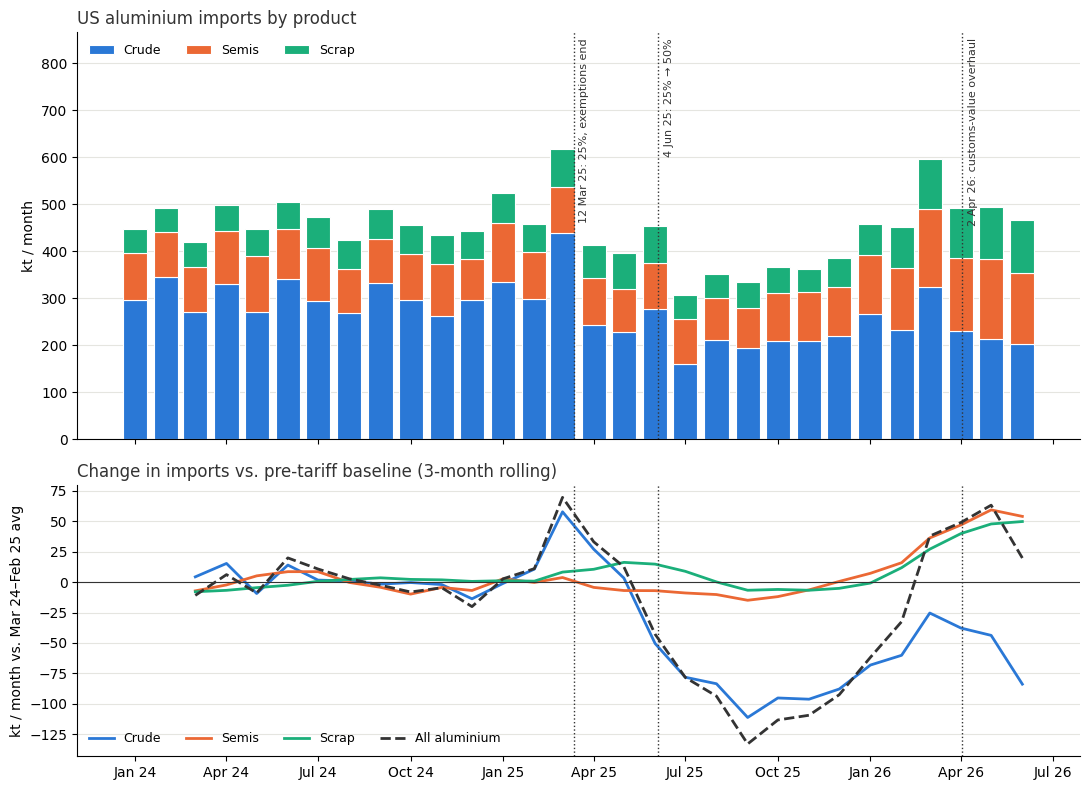

,Mar 24–Feb 25 (Canada 0%),Mar 25 (front-running),Apr–May 25 (25%),Jul 25–Mar 26 (50%),"Apr–Jun 26 (50%, new valuation)",50% vs. baseline (kt)
Crude,299.4,438.0,235.0,224.7,215.7,-74.7
Semis,104.5,98.6,97.0,111.7,158.3,7.2
Scrap,60.0,81.5,73.5,65.1,109.7,5.1
All aluminium,464.0,618.1,405.5,401.5,483.7,-62.5
Crude share (%),65.0,71.0,58.0,56.0,45.0,NaN


In [9]:
# US aluminium imports by product: crude (unwrought) vs. semis vs. scrap, all origins
by_product = (imports[imports["country"] == "Total"].set_index("date")
              [["crude_t", "semis_t", "scrap_t"]]
              .rename(columns={"crude_t": "Crude", "semis_t": "Semis", "scrap_t": "Scrap"})
              .loc["2024-01-01":] / 1e3)   # kt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                               gridspec_kw={"height_ratios": [3, 2]})

bottom = pd.Series(0.0, index=by_product.index)
for col, color in zip(by_product.columns, SERIES_COLORS):
    ax1.bar(by_product.index, by_product[col], bottom=bottom, width=24, color=color,
            edgecolor="white", linewidth=0.8, label=col)
    bottom += by_product[col]
ax1.set_ylabel("kt / month")
ax1.set_title("US aluminium imports by product", loc="left", color=INK)
ax1.set_ylim(0, by_product.sum(axis=1).max() * 1.4)
ax1.legend(loc="upper left", frameon=False, fontsize=9, ncol=3)

# Change vs. pre-tariff baseline (12 months to Feb 2025), 3-month rolling, in kt so the products add up
prod = by_product.assign(**{"All aluminium": by_product.sum(axis=1)})
base_prod = prod.loc["2024-03-01":"2025-02-01"].mean()
chg_prod = prod.rolling(3).mean() - base_prod
for col, color, ls in zip(chg_prod.columns, SERIES_COLORS[:3] + [INK], ["-", "-", "-", "--"]):
    ax2.plot(chg_prod.index, chg_prod[col], color=color, lw=2, ls=ls, label=col)
ax2.axhline(0, color=INK, lw=0.8)
ax2.set_ylabel("kt / month vs. Mar 24–Feb 25 avg")
ax2.set_title("Change in imports vs. pre-tariff baseline (3-month rolling)", loc="left", color=INK)
ax2.legend(loc="lower left", frameon=False, fontsize=9, ncol=4)

for ax in (ax1, ax2):
    for d in EVENTS:
        ax.axvline(d, color=INK, lw=1, ls=":")
    ax.grid(axis="y", color="#e5e5e0", lw=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
for d, label in EVENTS.items():
    ax1.annotate(label, xy=(d, ax1.get_ylim()[1]), xytext=(4, -4), textcoords="offset points",
                 fontsize=8, color=INK, rotation=90, va="top")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
fig.tight_layout()
plt.show()

# Average monthly imports (kt) by product in each tariff regime (same windows as the by-origin table)
regimes_prod = pd.DataFrame({k: prod.loc[a:b].mean() for k, (a, b) in WINDOWS.items()}).round(1)
regimes_prod.loc["Crude share (%)"] = (regimes_prod.loc["Crude"] / regimes_prod.loc["All aluminium"] * 100).round(0)
regimes_prod["50% vs. baseline (kt)"] = (regimes_prod["Jul 25–Mar 26 (50%)"] - regimes_prod["Mar 24–Feb 25 (Canada 0%)"]).round(1)
regimes_prod.loc["Crude share (%)", "50% vs. baseline (kt)"] = None
regimes_prod

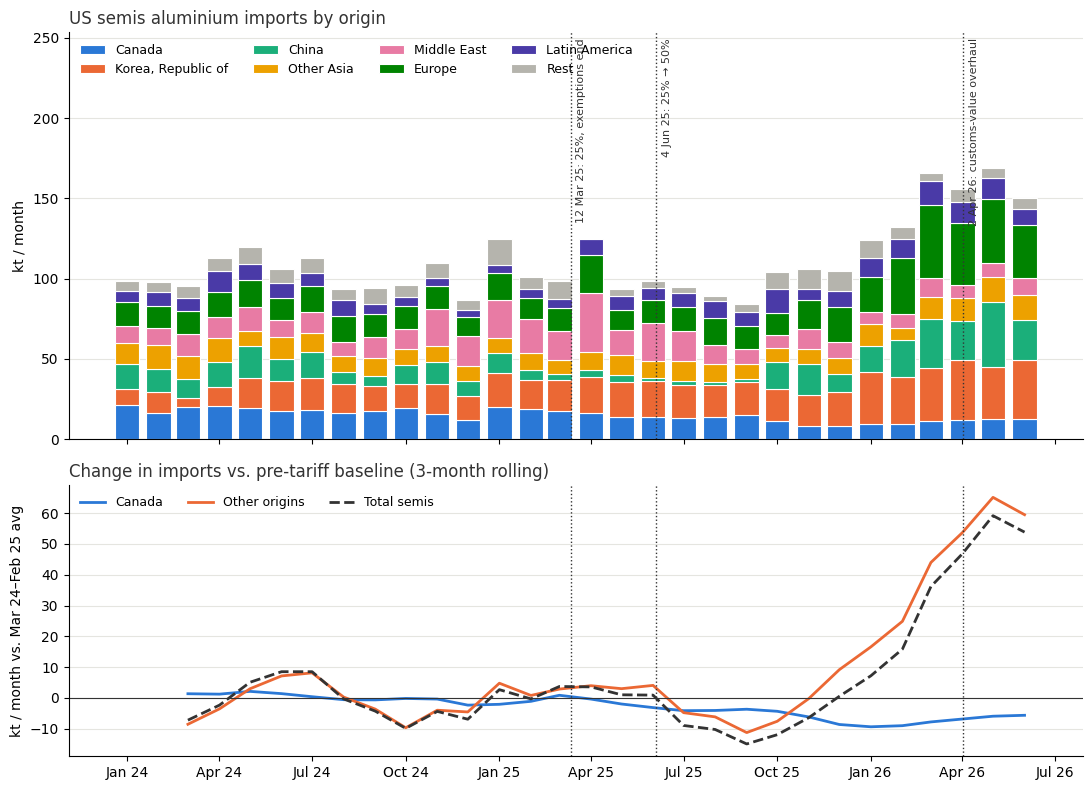

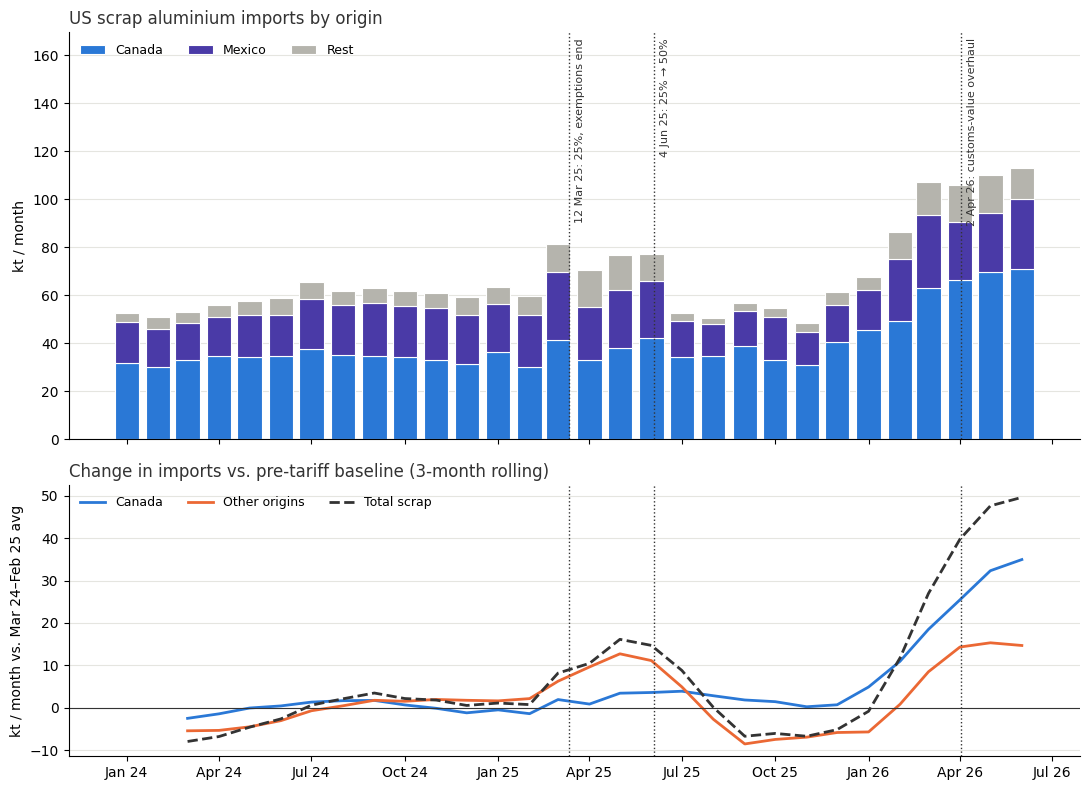

Mar 24–Feb 25 (Canada 0%)  Mar 25 (front-running)  \
      country                                                                 
Semis Canada                                   17.9                    17.6   
      Korea, Republic of                       16.5                    19.3   
      China                                    11.9                     3.7   
      Other Asia                               11.2                     8.6   
      Middle East                              15.5                    18.1   
      Europe                                   14.8                    14.5   
      Latin America                             7.5                     5.7   
      Rest                                      9.1                    11.1   
      Total                                   104.5                    98.6   
Scrap Canada                                   34.1                    41.5   
      Mexico                                   19.5                    28.1   
      Rest                                      6.4                    11.9   
      Total                                    60.0                    81.5   

                          Apr–May 25 (25%)  Jul 25–Mar 26 (50%)  \
      country                                                     
Semis Canada                          15.1                 11.2   
      Korea, Republic of              22.2                 23.9   
      China                            4.4                 13.8   
      Other Asia                      11.9                 10.7   
      Middle East                     25.9                 10.9   
      Europe                          18.5                 22.4   
      Latin America                    9.0                 11.0   
      Rest                             2.2                  7.9   
      Total                          108.9                111.7   
Scrap Canada                          35.5                 41.1   
      Mexico                          23.2                 18.1   
      Rest                            14.8                  5.9   
      Total                           73.5                 65.1   

                          Apr–Jun 26 (50%, new valuation)  \
      country                                               
Semis Canada                                         12.3   
      Korea, Republic of                             35.6   
      China                                          29.9   
      Other Asia                                     15.1   
      Middle East                                     9.4   
      Europe                                         36.9   
      Latin America                                  12.1   
      Rest                                            7.1   
      Total                                         158.3   
Scrap Canada                                         69.0   
      Mexico                                         25.8   
      Rest                                           14.8   
      Total                                         109.7   

                          50% vs. baseline (kt)  
      country                                    
Semis Canada                               -6.7  
      Korea, Republic of                    7.4  
      China                                 1.9  
      Other Asia                           -0.5  
      Middle East                          -4.6  
      Europe                                7.6  
      Latin America                         3.5  
      Rest                                 -1.2  
      Total                                 7.2  
Scrap Canada                                7.0  
      Mexico                               -1.4  
      Rest                                 -0.5  
      Total                                 5.1

In [10]:
# US semis and scrap imports by origin, same layout as the crude chart
# Semis are fragmented (~20 origins at 1-3% each), so beyond the three largest suppliers they are grouped by region.
# Scrap is almost all Canada + Mexico. "Other" is USGS's own unallocated bucket.
REGIONS = {
    "Other Asia":     ["Japan", "Taiwan", "Hong Kong", "Thailand", "Vietnam", "Indonesia", "Malaysia", "India"],
    "Middle East":    ["Oman", "Saudi Arabia", "Bahrain", "United Arab Emirates", "Qatar", "Turkey", "Azerbaijan"],
    "Europe":         ["Germany", "Greece", "Austria", "Belgium", "Sweden", "Spain", "United Kingdom", "Switzerland",
                       "Italy", "France", "Netherlands", "Norway", "Romania", "Poland", "Russia"],
    "Latin America":  ["Mexico", "Brazil", "Argentina", "Chile", "Colombia", "Costa Rica", "Ecuador",
                       "Guatemala", "Honduras", "Panama"],
}
PRODUCTS = {"semis_t": ("Semis", ["Canada", "Korea, Republic of", "China"], True),   # (label, named origins, group the rest by region)
            "scrap_t": ("Scrap", ["Canada", "Mexico"], False)}

# One colour per series across both figures; Canada keeps the blue it has in the crude chart.
# Mexico shares Latin America's colour since it is the bulk of that group.
COUNTRY_COLORS = {"Canada": "#2a78d6", "Korea, Republic of": "#eb6834", "China": "#1baf7a",
                  "Other Asia": "#eda100", "Middle East": "#e87ba4", "Europe": "#008300",
                  "Latin America": "#4a3aa7", "Mexico": "#4a3aa7", "Rest": "#b5b4ad"}

product_tables = {}
for col, (label, named, by_region) in PRODUCTS.items():
    by_country = (imports[imports["country"] != "Total"]
                  .pivot_table(index="date", columns="country", values=col, aggfunc="sum").fillna(0))
    total_p = imports[imports["country"] == "Total"].set_index("date")[col]
    fl = by_country[named].copy()
    if by_region:
        for region, members in REGIONS.items():
            fl[region] = by_country[[m for m in members if m in by_country and m not in named]].sum(axis=1)
    # Residual so the stack equals the reported total. Clipped at 0: in Apr 2025 (derived from YTD differences)
    # the semis country rows sum to ~25 kt more than the reported total, which would give a negative bar.
    fl["Rest"] = (total_p - fl.sum(axis=1)).clip(lower=0)
    fl = fl.loc["2024-01-01":] / 1e3        # kt

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                                   gridspec_kw={"height_ratios": [3, 2]})
    bottom = pd.Series(0.0, index=fl.index)
    for c in fl.columns:
        ax1.bar(fl.index, fl[c], bottom=bottom, width=24, color=COUNTRY_COLORS[c],
                edgecolor="white", linewidth=0.8, label=c)
        bottom += fl[c]
    ax1.set_ylabel("kt / month")
    ax1.set_title(f"US {label.lower()} aluminium imports by origin", loc="left", color=INK)
    ax1.set_ylim(0, fl.sum(axis=1).max() * 1.5)
    ax1.legend(loc="upper left", frameon=False, fontsize=9, ncol=4)

    # Change vs. pre-tariff baseline (12 months to Feb 2025), 3-month rolling, in kt
    g = pd.DataFrame({"Canada": fl["Canada"], "Other origins": fl.drop(columns="Canada").sum(axis=1)})
    g[f"Total {label.lower()}"] = g.sum(axis=1)
    chg = g.rolling(3).mean() - g.loc["2024-03-01":"2025-02-01"].mean()
    for c, color, ls in zip(chg.columns, [BLUE, ORANGE, INK], ["-", "-", "--"]):
        ax2.plot(chg.index, chg[c], color=color, lw=2, ls=ls, label=c)
    ax2.axhline(0, color=INK, lw=0.8)
    ax2.set_ylabel("kt / month vs. Mar 24–Feb 25 avg")
    ax2.set_title("Change in imports vs. pre-tariff baseline (3-month rolling)", loc="left", color=INK)
    ax2.legend(loc="upper left", frameon=False, fontsize=9, ncol=3)

    for ax in (ax1, ax2):
        for d in EVENTS:
            ax.axvline(d, color=INK, lw=1, ls=":")
        ax.grid(axis="y", color="#e5e5e0", lw=0.8)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)
    for d, txt in EVENTS.items():
        ax1.annotate(txt, xy=(d, ax1.get_ylim()[1]), xytext=(4, -4), textcoords="offset points",
                     fontsize=8, color=INK, rotation=90, va="top")
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
    fig.tight_layout()
    plt.show()

    t = fl.assign(**{"Total": fl.sum(axis=1)})
    product_tables[label] = pd.DataFrame({k: t.loc[a:b].mean() for k, (a, b) in WINDOWS.items()})

# Average monthly imports (kt) by origin in each tariff regime (same windows as the crude table)
regimes_sp = pd.concat(product_tables).round(1)
regimes_sp["50% vs. baseline (kt)"] = (regimes_sp["Jul 25–Mar 26 (50%)"] - regimes_sp["Mar 24–Feb 25 (Canada 0%)"]).round(1)
regimes_sp

Semis and scrap imports have risen in order to make up for the fall in the crude.

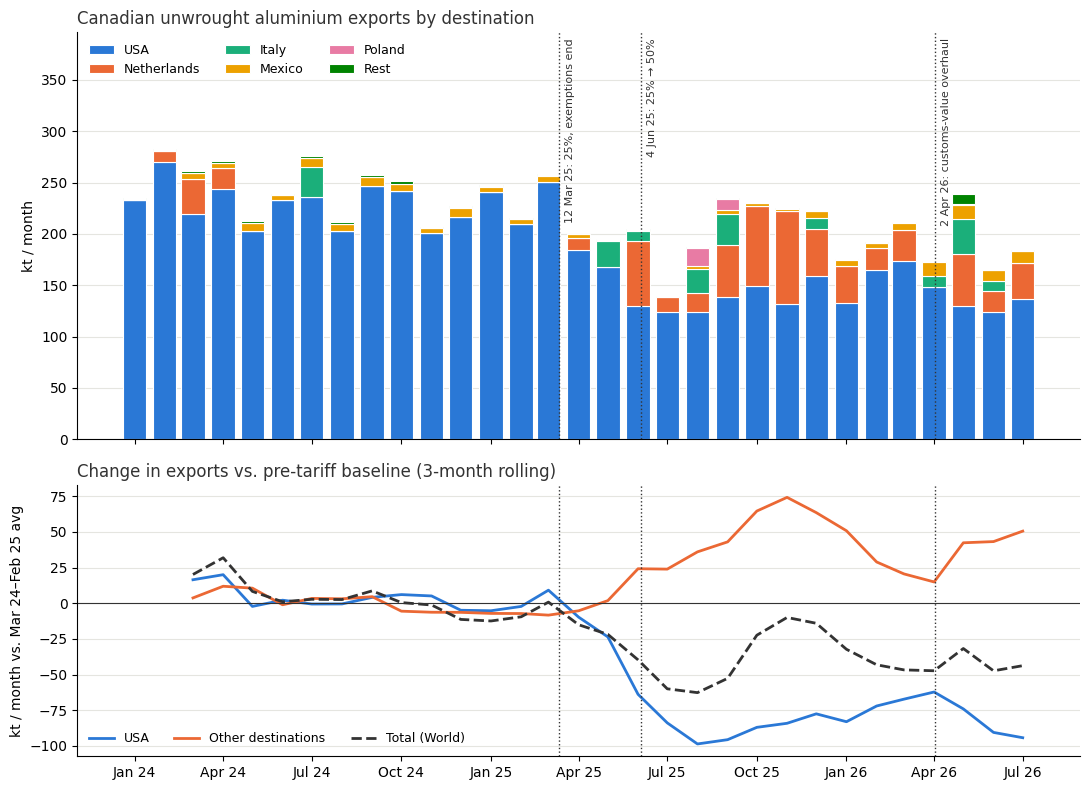

,Mar 24–Feb 25 (Canada 0%),Mar 25 (front-running),Apr–May 25 (25%),Jul 25–Mar 26 (50%),"Apr–Jul 26 (50%, new valuation)",50% vs. baseline (kt)
country,,,,,,
USA,224.4,250.5,175.8,144.2,134.6,-80.2
Netherlands,4.5,0.0,5.9,42.8,26.5,38.3
Italy,2.5,0.0,12.7,7.0,13.8,4.5
Mexico,6.6,6.1,2.3,4.2,12.4,-2.4
Poland,0.3,0.7,0.4,3.4,0.2,3.1
Rest,1.5,0.7,0.5,0.3,2.8,-1.2
Total (World),239.7,258.1,197.8,201.9,190.3,-37.8
US share (%),94.0,97.0,89.0,71.0,71.0,NaN


In [11]:
# Canadian unwrought aluminium exports (HS 7601) by destination around the tariff steps
ca = pd.read_csv(CANADA_EXPORTS, parse_dates=["date"])
ca = ca[ca["hs"] == 7601]   # HS 7602 (scrap) only runs to Oct 2024

exports = (ca[ca["country"] != "World"]
           .pivot_table(index="date", columns="country", values="tonnes", aggfunc="sum")
           .fillna(0))
world = ca[ca["country"] == "World"].set_index("date")["tonnes"]

# Main destinations: the largest since 2024; everything else folds into "Rest"
TOP_N = 4
dest = (exports.loc["2024-01-01":].sum()
        .sort_values(ascending=False).index[:TOP_N + 1].tolist())   # USA + next 4
ex = exports[dest].copy()
ex["Rest"] = world - ex.sum(axis=1)   # residual so the stack equals the reported World total
ex = ex.loc["2024-01-01":] / 1e3      # kt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                               gridspec_kw={"height_ratios": [3, 2]})

bottom = pd.Series(0.0, index=ex.index)
for col, color in zip(ex.columns, SERIES_COLORS):
    ax1.bar(ex.index, ex[col], bottom=bottom, width=24, color=color,
            edgecolor="white", linewidth=0.8, label=col)
    bottom += ex[col]
ax1.set_ylabel("kt / month")
ax1.set_title("Canadian unwrought aluminium exports by destination", loc="left", color=INK)
ax1.set_ylim(0, ex.sum(axis=1).max() * 1.4)
ax1.legend(loc="upper left", frameon=False, fontsize=9, ncol=3)

# Change vs. pre-tariff baseline (12 months to Feb 2025), 3-month rolling, by group.
# In kt rather than %: non-US destinations start from ~15 kt/month, so their % change is huge and uninformative
groups_ca = pd.DataFrame({"USA": ex["USA"],
                          "Other destinations": ex.drop(columns="USA").sum(axis=1)})
groups_ca["Total (World)"] = groups_ca.sum(axis=1)
base_ca = groups_ca.loc["2024-03-01":"2025-02-01"].mean()
chg_ca = groups_ca.rolling(3).mean() - base_ca
for col, color, ls in zip(chg_ca.columns, [BLUE, ORANGE, INK], ["-", "-", "--"]):
    ax2.plot(chg_ca.index, chg_ca[col], color=color, lw=2, ls=ls, label=col)
ax2.axhline(0, color=INK, lw=0.8)
ax2.set_ylabel("kt / month vs. Mar 24–Feb 25 avg")
ax2.set_title("Change in exports vs. pre-tariff baseline (3-month rolling)", loc="left", color=INK)
ax2.legend(loc="lower left", frameon=False, fontsize=9, ncol=3)

for ax in (ax1, ax2):
    for d in EVENTS:
        ax.axvline(d, color=INK, lw=1, ls=":")
    ax.grid(axis="y", color="#e5e5e0", lw=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
for d, label in EVENTS.items():
    ax1.annotate(label, xy=(d, ax1.get_ylim()[1]), xytext=(4, -4), textcoords="offset points",
                 fontsize=8, color=INK, rotation=90, va="top")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
fig.tight_layout()
plt.show()

# Average monthly exports (kt) in each tariff regime, full months only
WINDOWS_CA = {
    "Mar 24–Feb 25 (Canada 0%)":       ("2024-03-01", "2025-02-01"),
    "Mar 25 (front-running)":          ("2025-03-01", "2025-03-01"),
    "Apr–May 25 (25%)":                ("2025-04-01", "2025-05-01"),
    "Jul 25–Mar 26 (50%)":             ("2025-07-01", "2026-03-01"),
    "Apr–Jul 26 (50%, new valuation)": ("2026-04-01", "2026-07-01"),
}
table_ca = ex.assign(**{"Total (World)": ex.sum(axis=1)})
regimes_ca = pd.DataFrame({k: table_ca.loc[a:b].mean() for k, (a, b) in WINDOWS_CA.items()}).round(1)
regimes_ca.loc["US share (%)"] = (regimes_ca.loc["USA"] / regimes_ca.loc["Total (World)"] * 100).round(0)
regimes_ca["50% vs. baseline (kt)"] = (regimes_ca["Jul 25–Mar 26 (50%)"] - regimes_ca["Mar 24–Feb 25 (Canada 0%)"]).round(1)
regimes_ca.loc["US share (%)", "50% vs. baseline (kt)"] = None
regimes_ca

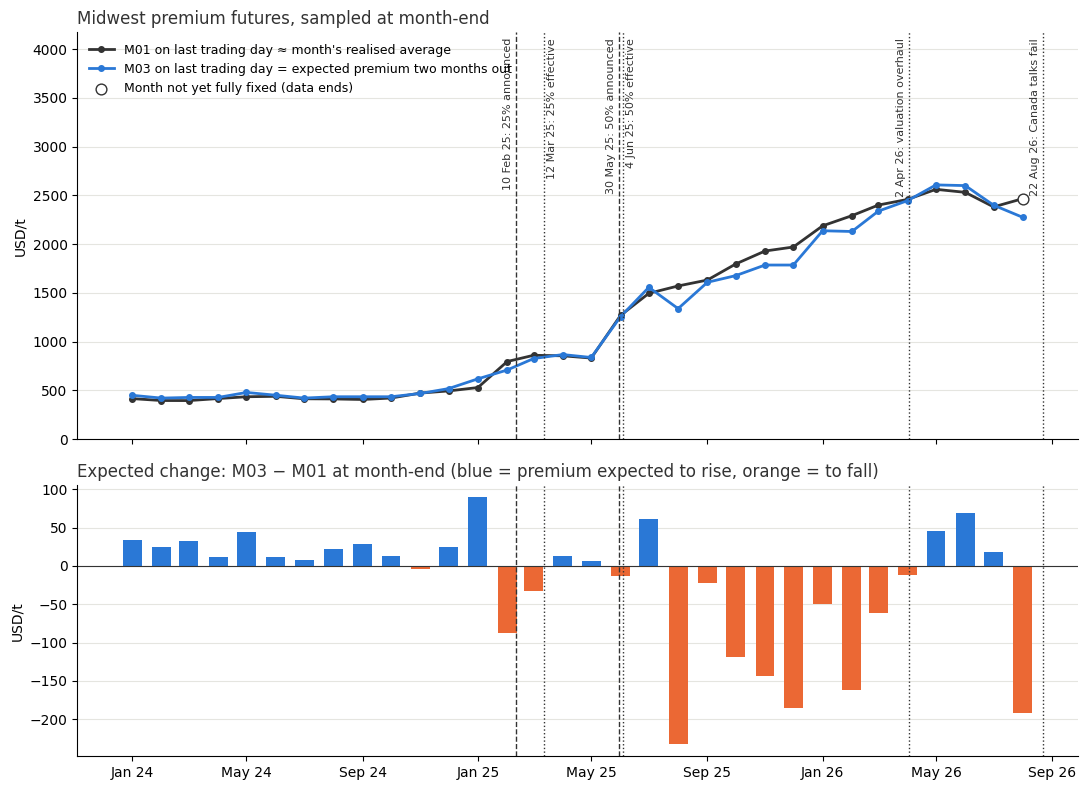

In [12]:
# MW premium curve sampled once a month, on the last trading day.
# Each contract settles on the average of that month's daily Platts assessments, so M01 is part-fixed during the
# month and only at month-end equals the month's (nearly) realised average. Sampling on that day makes the slope
# read cleanly: M03 − M01 = premium the market expects two months out − this month's realised average.
# A daily M03 − M01 instead mixes a part-fixed average with a forecast, and jumps every time M01 rolls.
# Caveat: M02+ are unchanged on ~80% of days since 2024 and often equal each other, so M03 is a coarse forecast.
curve = mwp_futures.pivot(index="date", columns="tenor", values="premium_usd_t").loc["2024-01-01":]

CURVE_EVENTS = {   # (label, line style, label side): dashed = announcement, dotted = effective date
    pd.Timestamp("2025-02-10"): ("10 Feb 25: 25% announced", "--", "left"),
    pd.Timestamp("2025-03-12"): ("12 Mar 25: 25% effective", ":", "right"),
    pd.Timestamp("2025-05-30"): ("30 May 25: 50% announced", "--", "left"),
    TARIFF_DATE:                ("4 Jun 25: 50% effective", ":", "right"),
    pd.Timestamp("2026-04-02"): ("2 Apr 26: valuation overhaul", ":", "left"),
    pd.Timestamp("2026-08-22"): ("22 Aug 26: Canada talks fail", ":", "left"),
}

last_day = curve.groupby(curve.index.to_period("M")).tail(1)
me = pd.DataFrame({"realised": last_day[1].values, "m03": last_day[3].values,
                   "trade_date": last_day.index}, index=last_day.index.to_period("M").to_timestamp())
me["slope"] = me["m03"] - me["realised"]
# The data ends mid-month (28 Aug 26 is not the last business day of August), so the last month is not fully fixed.
# Only the last row is checked: earlier months can end before the business month-end on holidays (Good Friday).
partial = pd.Series(False, index=me.index)
partial.iloc[-1] = me["trade_date"].iloc[-1] < me.index[-1] + pd.offsets.BMonthEnd(0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                               gridspec_kw={"height_ratios": [3, 2]})
ax1.plot(me.index, me["realised"], color=INK, lw=2, marker="o", ms=4,
         label="M01 on last trading day ≈ month's realised average")
ax1.plot(me.index, me["m03"], color=BLUE, lw=2, marker="o", ms=4,
         label="M03 on last trading day = expected premium two months out")
if partial.any():
    ax1.scatter(me.index[partial], me.loc[partial, "realised"], s=60, facecolors="white", edgecolors=INK, zorder=3,
                label="Month not yet fully fixed (data ends)")
ax1.set_ylabel("USD/t")
ax1.set_title("Midwest premium futures, sampled at month-end", loc="left", color=INK)
ax1.set_ylim(0, me[["realised", "m03"]].max().max() * 1.6)
ax1.legend(loc="upper left", frameon=False, fontsize=9)

ax2.bar(me.index, me["slope"], width=20, color=[BLUE if s >= 0 else ORANGE for s in me["slope"]])
ax2.axhline(0, color=INK, lw=0.8)
ax2.set_ylabel("USD/t")
ax2.set_title("Expected change: M03 − M01 at month-end (blue = premium expected to rise, orange = to fall)",
              loc="left", color=INK)

for ax in (ax1, ax2):
    for d, (_, ls, _) in CURVE_EVENTS.items():
        ax.axvline(d, color=INK, lw=1, ls=ls)
    ax.grid(axis="y", color="#e5e5e0", lw=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
for d, (label, _, side) in CURVE_EVENTS.items():
    ax1.annotate(label, xy=(d, ax1.get_ylim()[1]), xytext=(-2 if side == "left" else 2, -4),
                 textcoords="offset points", fontsize=8, color=INK, rotation=90, va="top",
                 ha="right" if side == "left" else "left")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
fig.tight_layout()
plt.show()


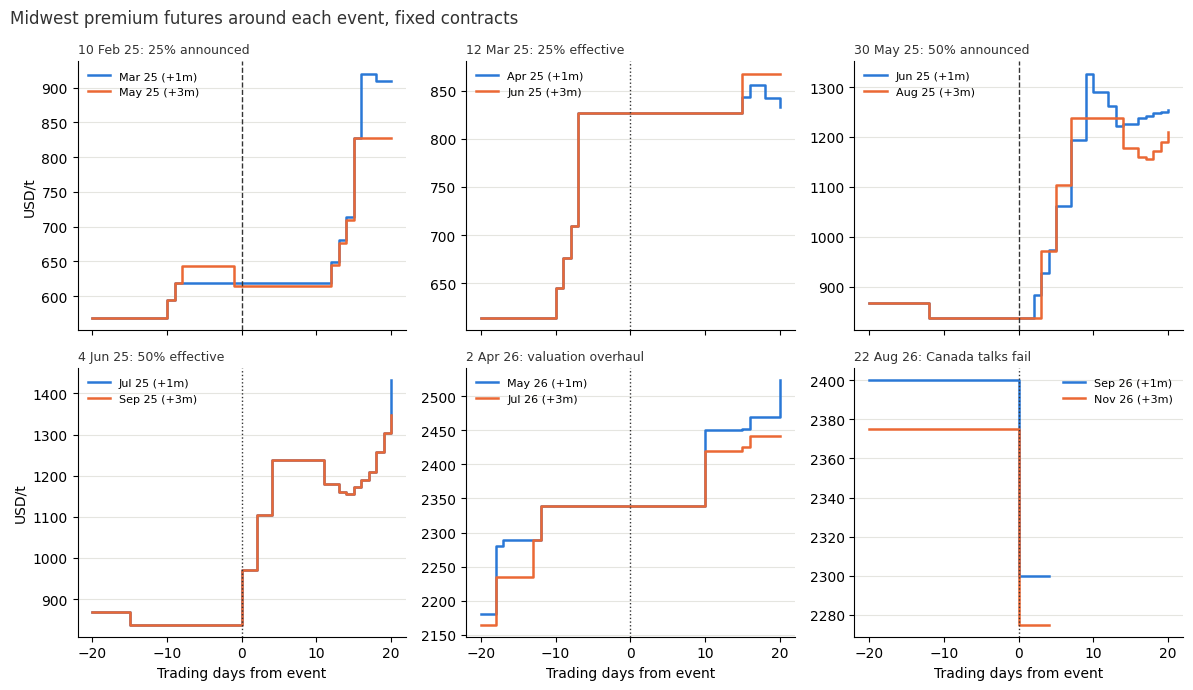

+1m                              +3m  \
                             contract   before  Δ +5d  Δ +20d contract   
10 Feb 25: 25% announced       Mar 25   618.98    0.0  290.48   May 25   
12 Mar 25: 25% effective       Apr 25   827.23    0.0    5.97   Jun 25   
30 May 25: 50% announced       Jun 25    838.0  223.0  415.01   Aug 25   
4 Jun 25: 50% effective        Jul 25    838.0  399.0   593.9   Sep 25   
2 Apr 26: valuation overhaul   May 26  2339.24    0.0  183.95   Jul 26   
22 Aug 26: Canada talks fail   Sep 26   2400.0    NaN     NaN   Nov 26   

                                                      
                               before  Δ +5d  Δ +20d  
10 Feb 25: 25% announced       613.98    0.0  213.25  
12 Mar 25: 25% effective       827.23    0.0   40.77  
30 May 25: 50% announced        838.0  266.0  372.12  
4 Jun 25: 50% effective         838.0  399.0  510.35  
2 Apr 26: valuation overhaul  2339.24    0.0  101.76  
22 Aug 26: Canada talks fail   2375.0    NaN     NaN

In [13]:
# Event windows on FIXED contracts. The rolling M01/M03 columns switch contract on the first trading day of each
# month, and M01 is part-fixed by the month's assessments, so they mix contracts and damp jumps.
# Instead follow the contracts for event month +1 (no days fixed yet) and +3, 20 trading days either side.
by_contract = (mwp_futures.assign(contract_month=pd.to_datetime(mwp_futures["contract_month"]))
               .pivot_table(index="date", columns="contract_month", values="premium_usd_t"))
WINDOW = 20   # trading days either side

fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True)
for ax, (d, (label, ls, _)) in zip(axes.flat, CURVE_EVENTS.items()):
    for ahead, color in [(1, BLUE), (3, ORANGE)]:
        cm = (d.to_period("M") + ahead).to_timestamp()
        s_ = by_contract[cm].dropna()
        i = s_.index.searchsorted(d)   # first trading day on/after the date
        win = s_.iloc[max(i - WINDOW, 0): i + WINDOW + 1]
        x = range(-min(i, WINDOW), -min(i, WINDOW) + len(win))
        ax.step(list(x), win.values, where="post", color=color, lw=1.8, label=f"{cm:%b %y} (+{ahead}m)")
    ax.axvline(0, color=INK, lw=1, ls=ls)
    ax.set_title(label, loc="left", fontsize=9, color=INK)
    ax.legend(loc="best", frameon=False, fontsize=8)
    ax.grid(axis="y", color="#e5e5e0", lw=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes[1]:
    ax.set_xlabel("Trading days from event")
for ax in axes[:, 0]:
    ax.set_ylabel("USD/t")
fig.suptitle("Midwest premium futures around each event, fixed contracts", x=0.01, ha="left", color=INK)
fig.tight_layout()
plt.show()

def settle_around(series, date, offset):
    series = series.dropna()
    i = series.index.searchsorted(date)   # first trading day on/after the date
    if offset < 0:
        return series.iloc[i - 1]
    return series.iloc[i + offset] if i + offset < len(series) else float("nan")   # past the end of the data

rows = {}
for d, (label, _, _) in CURVE_EVENTS.items():
    r_ = {}
    for ahead in (1, 3):
        cm = (d.to_period("M") + ahead).to_timestamp()
        s_ = by_contract[cm]
        before = settle_around(s_, d, -1)
        key = f"+{ahead}m"
        r_[(key, "contract")] = f"{cm:%b %y}"
        r_[(key, "before")] = before
        r_[(key, "Δ +5d")] = settle_around(s_, d, 5) - before
        r_[(key, "Δ +20d")] = settle_around(s_, d, 20) - before
    rows[label] = r_
event_moves = pd.DataFrame(rows).T
event_moves.columns = pd.MultiIndex.from_tuples(event_moves.columns)
event_moves


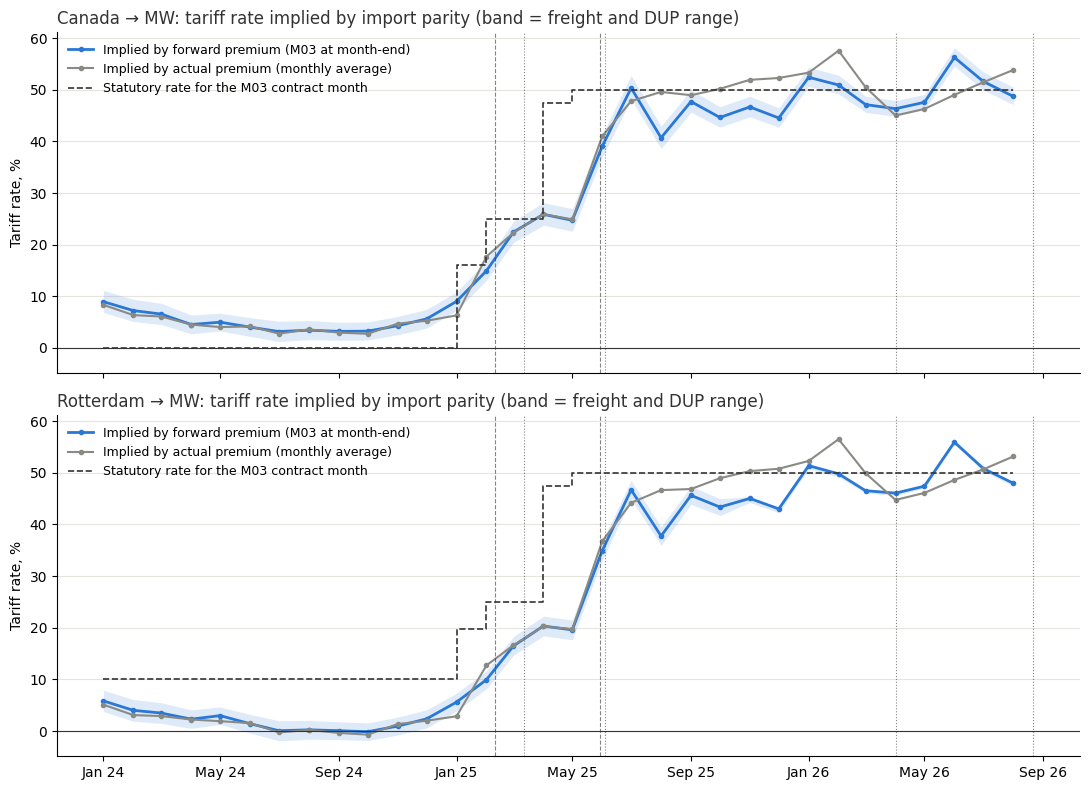

actual  forward  expected change
Canada    Jan 24–Jan 25 (Canada 0%)     4.8      5.3              0.5
          Apr–May 25 (25%)             25.4     25.3             -0.1
          Jul–Dec 25 (50%)             50.1     45.8             -4.4
          Jan–Aug 26 (50%)             50.9     50.1             -0.8
Rotterdam Jan 24–Jan 25 (Canada 0%)     1.7      2.2              0.6
          Apr–May 25 (25%)             20.0     20.0             -0.0
          Jul–Dec 25 (50%)             48.0     43.6             -4.4
          Jan–Aug 26 (50%)             50.3     49.5             -0.8

In [14]:
# Implied tariff rate: the rate at which import parity explains the MW premium.
# Parity premium at tariff t (landed cost − LME, as in the route model above):
#   Canada:    MWP* = (DP − F_netback) + F_ca_mw + t × (LME + DP − F_netback)
#   Rotterdam: MWP* = DUP + F_rtm_mw + t × (LME + DUP)
# Solved for t, once with the actual premium (monthly average, LME cash) and once with the forward premium
# (M03 on the last trading day, LME 3M on that day; DP / DUP held at this month's level, no forward exists).
#   forward-implied < actual-implied: the market prices a lower landed cost two months out.
#   forward-implied < statutory rate: a premium below import parity, which supply can't deliver; it takes a
#   lower tariff (or lower DP/DUP, which the flat-premium assumption can't rule out).
# Caveat: before 2025 the Canada route already sat ~150 $/t above parity at 0% (implied rate > 0), so read
# changes against that baseline rather than the level alone.
lme3m_me = lme.set_index("date")["three_month"].groupby(lambda d: d.to_period("M").to_timestamp()).last()
imp = r.join(me[["m03"]], how="inner").join(lme3m_me.rename("lme3m"), how="inner")

def implied(prem, lme_px, p, f_dest):
    return (prem - p - f_dest) / (lme_px + p)

rows = {}
for name, f in [("lo", lo), ("mid", mid), ("hi", hi)]:
    # Higher freight -> more of the premium is freight -> lower implied tariff, so "lo" freight gives the upper bound
    p_ca = imp["dp"] - FREIGHT["ca_rtm"][2 - f]   # larger netback freight lowers Canada's FOB
    f_ca = FREIGHT["ca_mw"][f]
    dup = {"lo": imp["dup_hi"], "mid": imp["dup"], "hi": imp["dup_lo"]}[name]
    f_rtm = FREIGHT["rtm_mw"][f]
    rows[f"ca_actual_{name}"] = implied(imp["mwp"], imp["lme"], p_ca, f_ca)
    rows[f"ca_fwd_{name}"] = implied(imp["m03"], imp["lme3m"], p_ca, f_ca)
    rows[f"rtm_actual_{name}"] = implied(imp["mwp"], imp["lme"], dup, f_rtm)
    rows[f"rtm_fwd_{name}"] = implied(imp["m03"], imp["lme3m"], dup, f_rtm)
implied_t = pd.DataFrame(rows) * 100
# Statutory rate for the contract M03 refers to (two months out), from the schedule as known today
fwd_month = imp.index + pd.DateOffset(months=2)
implied_t["stat_ca"] = [tariff_rate(d, "Canada") * 100 for d in fwd_month]
implied_t["stat_ot"] = [tariff_rate(d, "Other") * 100 for d in fwd_month]
plot_t = implied_t.loc["2024-01-01":]

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True, sharey=True)
for ax, (route, title, stat) in zip(axes, [("ca", "Canada → MW", "stat_ca"), ("rtm", "Rotterdam → MW", "stat_ot")]):
    ax.fill_between(plot_t.index, plot_t[f"{route}_fwd_hi"], plot_t[f"{route}_fwd_lo"], color=BLUE, alpha=0.15, lw=0)
    ax.plot(plot_t.index, plot_t[f"{route}_fwd_mid"], color=BLUE, lw=2, marker="o", ms=3,
            label="Implied by forward premium (M03 at month-end)")
    ax.plot(plot_t.index, plot_t[f"{route}_actual_mid"], color=MUTED, lw=1.5, marker="o", ms=3,
            label="Implied by actual premium (monthly average)")
    ax.step(plot_t.index, plot_t[stat], where="post", color=INK, lw=1.2, ls="--",
            label="Statutory rate for the M03 contract month")
    ax.axhline(0, color=INK, lw=0.8)
    ax.set_ylabel("Tariff rate, %")
    ax.set_title(f"{title}: tariff rate implied by import parity (band = freight and DUP range)",
                 loc="left", color=INK)
    ax.legend(loc="upper left", frameon=False, fontsize=9)
    for d, (_, ls, _) in CURVE_EVENTS.items():
        ax.axvline(d, color=INK, lw=0.8, ls=ls, alpha=0.6)
    ax.grid(axis="y", color="#e5e5e0", lw=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
fig.tight_layout()
plt.show()

# Averages by regime, mid freight (percentage points). "expected change" = forward − actual implied rate
REGIMES_T = {
    "Jan 24–Jan 25 (Canada 0%)": ("2024-01-01", "2025-01-01"),
    "Apr–May 25 (25%)":          ("2025-04-01", "2025-05-01"),
    "Jul–Dec 25 (50%)":          ("2025-07-01", "2025-12-01"),
    "Jan–Aug 26 (50%)":          ("2026-01-01", None),
}
summ = {}
for route, label in [("ca", "Canada"), ("rtm", "Rotterdam")]:
    t_ = implied_t[[f"{route}_actual_mid", f"{route}_fwd_mid"]].rename(
        columns={f"{route}_actual_mid": "actual", f"{route}_fwd_mid": "forward"})
    t_["expected change"] = t_["forward"] - t_["actual"]
    for k, (a, b) in REGIMES_T.items():
        summ[(label, k)] = t_.loc[a:b].mean()
pd.DataFrame(summ).T.round(1)
